In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from pathlib import Path
import gc

PROCESSED = Path("../data/processed")
REPORTS = Path("reports")
REPORTS.mkdir(exist_ok=True)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
sns.set_style("whitegrid")

In [2]:
train = pd.read_parquet(PROCESSED / "application_train.parquet")
test = pd.read_parquet(PROCESSED / "application_test.parquet")

print(f"Train: {train.shape} | Test: {test.shape}")
print(f"Columnas en train no en test: {set(train.columns) - set(test.columns)}")
# Debería imprimir solo {'TARGET'}

Train: (307511, 122) | Test: (48744, 121)
Columnas en train no en test: {'TARGET'}


Distribución del TARGET:
         count    pct
TARGET               
0       282686  91.93
1        24825   8.07

Ratio desbalance (0:1): 11.39 : 1


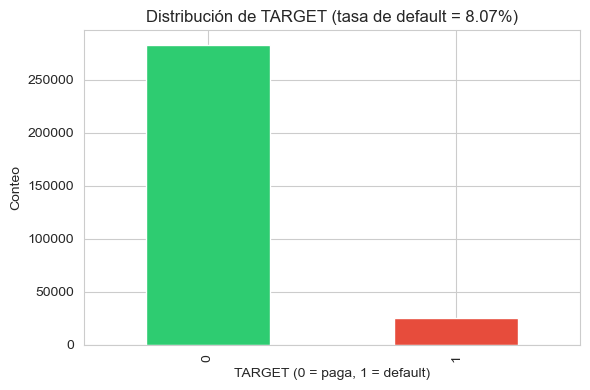

In [3]:
target_counts = train["TARGET"].value_counts()
target_pct = train["TARGET"].value_counts(normalize=True) * 100

print("Distribución del TARGET:")
print(pd.DataFrame({"count": target_counts, "pct": target_pct.round(2)}))
print(f"\nRatio desbalance (0:1): {target_counts[0] / target_counts[1]:.2f} : 1")

fig, ax = plt.subplots(figsize=(6, 4))
target_counts.plot(kind="bar", ax=ax, color=["#2ecc71", "#e74c3c"])
ax.set_title(f"Distribución de TARGET (tasa de default = {target_pct[1]:.2f}%)")
ax.set_xlabel("TARGET (0 = paga, 1 = default)")
ax.set_ylabel("Conteo")
plt.tight_layout()
plt.savefig(REPORTS / "target_distribution.png", dpi=100, bbox_inches="tight")
plt.show()

In [4]:
days_cols = [c for c in train.columns if c.startswith("DAYS_")]
print(f"Columnas DAYS_*: {days_cols}\n")

sentinel_report = []
for col in days_cols:
    n = (train[col] == 365243).sum()
    if n > 0:
        sentinel_report.append({
            "columna": col,
            "n_365243": int(n),
            "pct": round(100 * n / len(train), 2),
        })

if sentinel_report:
    print("Centinelas 365243 encontrados:")
    print(pd.DataFrame(sentinel_report))
else:
    print("No se encontraron centinelas 365243 en columnas DAYS_*")

Columnas DAYS_*: ['DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'DAYS_LAST_PHONE_CHANGE']

Centinelas 365243 encontrados:
         columna  n_365243    pct
0  DAYS_EMPLOYED     55374  18.01


In [5]:
object_cols = train.select_dtypes(include="object").columns.tolist()
print(f"Total columnas object: {len(object_cols)}\n")

cat_anom = []
for col in object_cols:
    vc = train[col].value_counts(dropna=False)
    for sentinel in ["XNA", "XAP", "Unknown"]:
        if sentinel in vc.index:
            cat_anom.append({
                "columna": col,
                "valor": sentinel,
                "conteo": int(vc[sentinel]),
                "pct": round(100 * vc[sentinel] / len(train), 2),
            })

if cat_anom:
    print("Categorías centinela encontradas:")
    print(pd.DataFrame(cat_anom).sort_values("conteo", ascending=False))
else:
    print("No se encontraron XNA/XAP/Unknown")

Total columnas object: 16

Categorías centinela encontradas:
              columna    valor  conteo    pct
2   ORGANIZATION_TYPE      XNA   55374  18.01
0         CODE_GENDER      XNA       4   0.00
1  NAME_FAMILY_STATUS  Unknown       2   0.00


In [6]:
suspicious = ["FONDKAPREMONT_MODE", "HOUSETYPE_MODE", "WALLSMATERIAL_MODE",
              "EMERGENCYSTATE_MODE", "OCCUPATION_TYPE", "NAME_TYPE_SUITE"]

for col in suspicious:
    if col in train.columns:
        n_nan = train[col].isna().sum()
        unique_sample = train[col].dropna().unique()[:5]
        print(f"{col:30s} | NaN={n_nan:>7,} | ej. valores: {list(unique_sample)}")

FONDKAPREMONT_MODE             | NaN=210,295 | ej. valores: ['reg oper account', 'org spec account', 'reg oper spec account', 'not specified']
HOUSETYPE_MODE                 | NaN=154,297 | ej. valores: ['block of flats', 'terraced house', 'specific housing']
WALLSMATERIAL_MODE             | NaN=156,341 | ej. valores: ['Stone, brick', 'Block', 'Panel', 'Mixed', 'Wooden']
EMERGENCYSTATE_MODE            | NaN=145,755 | ej. valores: ['No', 'Yes']
OCCUPATION_TYPE                | NaN= 96,391 | ej. valores: ['Laborers', 'Core staff', 'Accountants', 'Managers', 'Drivers']
NAME_TYPE_SUITE                | NaN=  1,292 | ej. valores: ['Unaccompanied', 'Family', 'Spouse, partner', 'Children', 'Other_A']


In [7]:
def clean_application(df):
    """
    Limpia application_train/test:
      - 365243 → NaN en DAYS_* (con indicador _ANOM)
      - XNA / XAP → NaN en categóricas
      - Crea variables YEARS_* (positivas) para análisis e interpretación
    """
    df = df.copy()

    # 1) Centinelas numéricos en DAYS_*
    for col in [c for c in df.columns if c.startswith("DAYS_")]:
        mask = df[col] == 365243
        if mask.any():
            df[f"{col}_ANOM"] = mask.astype("int8")
            df.loc[mask, col] = np.nan

    # 2) Centinelas categóricos
    for col in df.select_dtypes(include="object").columns:
        df[col] = df[col].replace({"XNA": np.nan, "XAP": np.nan})

    # 3) Versiones en años (positivas) para EDA
    days_to_years = {
        "DAYS_BIRTH": "AGE_YEARS",
        "DAYS_EMPLOYED": "EMPLOYMENT_YEARS",
        "DAYS_REGISTRATION": "YEARS_SINCE_REGISTRATION",
        "DAYS_ID_PUBLISH": "YEARS_SINCE_ID_PUBLISH",
        "DAYS_LAST_PHONE_CHANGE": "YEARS_SINCE_PHONE_CHANGE",
    }
    for src, dst in days_to_years.items():
        if src in df.columns:
            df[dst] = (-df[src] / 365.25).astype("float32")

    return df

train_clean = clean_application(train)
test_clean = clean_application(test)

print(f"Train: {train.shape} → {train_clean.shape}")
print(f"Test:  {test.shape} → {test_clean.shape}")
print(f"\nNuevas columnas en train: {sorted(set(train_clean.columns) - set(train.columns))}")

Train: (307511, 122) → (307511, 128)
Test:  (48744, 121) → (48744, 127)

Nuevas columnas en train: ['AGE_YEARS', 'DAYS_EMPLOYED_ANOM', 'EMPLOYMENT_YEARS', 'YEARS_SINCE_ID_PUBLISH', 'YEARS_SINCE_PHONE_CHANGE', 'YEARS_SINCE_REGISTRATION']


In [8]:
print("=== Verificación de centinelas ===")
print(f"Antes:    DAYS_EMPLOYED == 365243 → {(train['DAYS_EMPLOYED'] == 365243).sum():,}")
print(f"Después:  DAYS_EMPLOYED == 365243 → {(train_clean['DAYS_EMPLOYED'] == 365243).sum():,}")
print(f"Indicador DAYS_EMPLOYED_ANOM == 1 → {(train_clean['DAYS_EMPLOYED_ANOM'] == 1).sum():,}")

print("\n=== Estadísticas de variables YEARS_* ===")
years_cols = ["AGE_YEARS", "EMPLOYMENT_YEARS", "YEARS_SINCE_REGISTRATION",
              "YEARS_SINCE_ID_PUBLISH", "YEARS_SINCE_PHONE_CHANGE"]
print(train_clean[years_cols].describe().round(2))

print("\n=== CODE_GENDER después de limpiar XNA ===")
print(train_clean["CODE_GENDER"].value_counts(dropna=False))

=== Verificación de centinelas ===
Antes:    DAYS_EMPLOYED == 365243 → 55,374
Después:  DAYS_EMPLOYED == 365243 → 0
Indicador DAYS_EMPLOYED_ANOM == 1 → 55,374

=== Estadísticas de variables YEARS_* ===
       AGE_YEARS  EMPLOYMENT_YEARS  YEARS_SINCE_REGISTRATION  YEARS_SINCE_ID_PUBLISH  YEARS_SINCE_PHONE_CHANGE
count  307511.00         252137.00                 307511.00               307511.00                 307510.00
mean       43.91              6.53                     13.65                    8.20                      2.64
std        11.95              6.40                      9.64                    4.13                      2.26
min        20.50             -0.00                     -0.00                    0.00                     -0.00
25%        33.98              2.10                      5.50                    4.71                      0.75
50%        43.12              4.51                     12.33                    8.91                      2.07
75%        53.89     

In [9]:
nulls = train_clean.isna().sum()
nulls_pct = (100 * nulls / len(train_clean)).round(2)
nulls_df = pd.DataFrame({
    "n_nulls": nulls,
    "pct_nulls": nulls_pct,
    "dtype": train_clean.dtypes.astype(str),
}).sort_values("pct_nulls", ascending=False)

print("Top 30 columnas con más nulos:")
print(nulls_df.head(30))

print("\n=== Distribución de columnas por banda de % nulos ===")
bins = [-0.01, 0.001, 10, 30, 50, 70, 100]
labels = ["0%", "0-10%", "10-30%", "30-50%", "50-70%", "70-100%"]
nulls_df["banda"] = pd.cut(nulls_df["pct_nulls"], bins=bins, labels=labels)
print(nulls_df["banda"].value_counts().sort_index())

nulls_df.to_csv(REPORTS / "missingness_ranking_train.csv")
print(f"\nGuardado: {REPORTS / 'missingness_ranking_train.csv'}")

Top 30 columnas con más nulos:
                          n_nulls  pct_nulls    dtype
COMMONAREA_AVG             214865      69.87  float32
COMMONAREA_MODE            214865      69.87  float32
COMMONAREA_MEDI            214865      69.87  float32
NONLIVINGAPARTMENTS_AVG    213514      69.43  float32
NONLIVINGAPARTMENTS_MODE   213514      69.43  float32
NONLIVINGAPARTMENTS_MEDI   213514      69.43  float32
FONDKAPREMONT_MODE         210295      68.39   object
LIVINGAPARTMENTS_AVG       210199      68.35  float32
LIVINGAPARTMENTS_MEDI      210199      68.35  float32
LIVINGAPARTMENTS_MODE      210199      68.35  float32
FLOORSMIN_MODE             208642      67.85  float32
FLOORSMIN_MEDI             208642      67.85  float32
FLOORSMIN_AVG              208642      67.85  float32
YEARS_BUILD_AVG            204488      66.50  float32
YEARS_BUILD_MODE           204488      66.50  float32
YEARS_BUILD_MEDI           204488      66.50  float32
OWN_CAR_AGE                202929      65.99  float

Columnas con al menos un nulo: 72


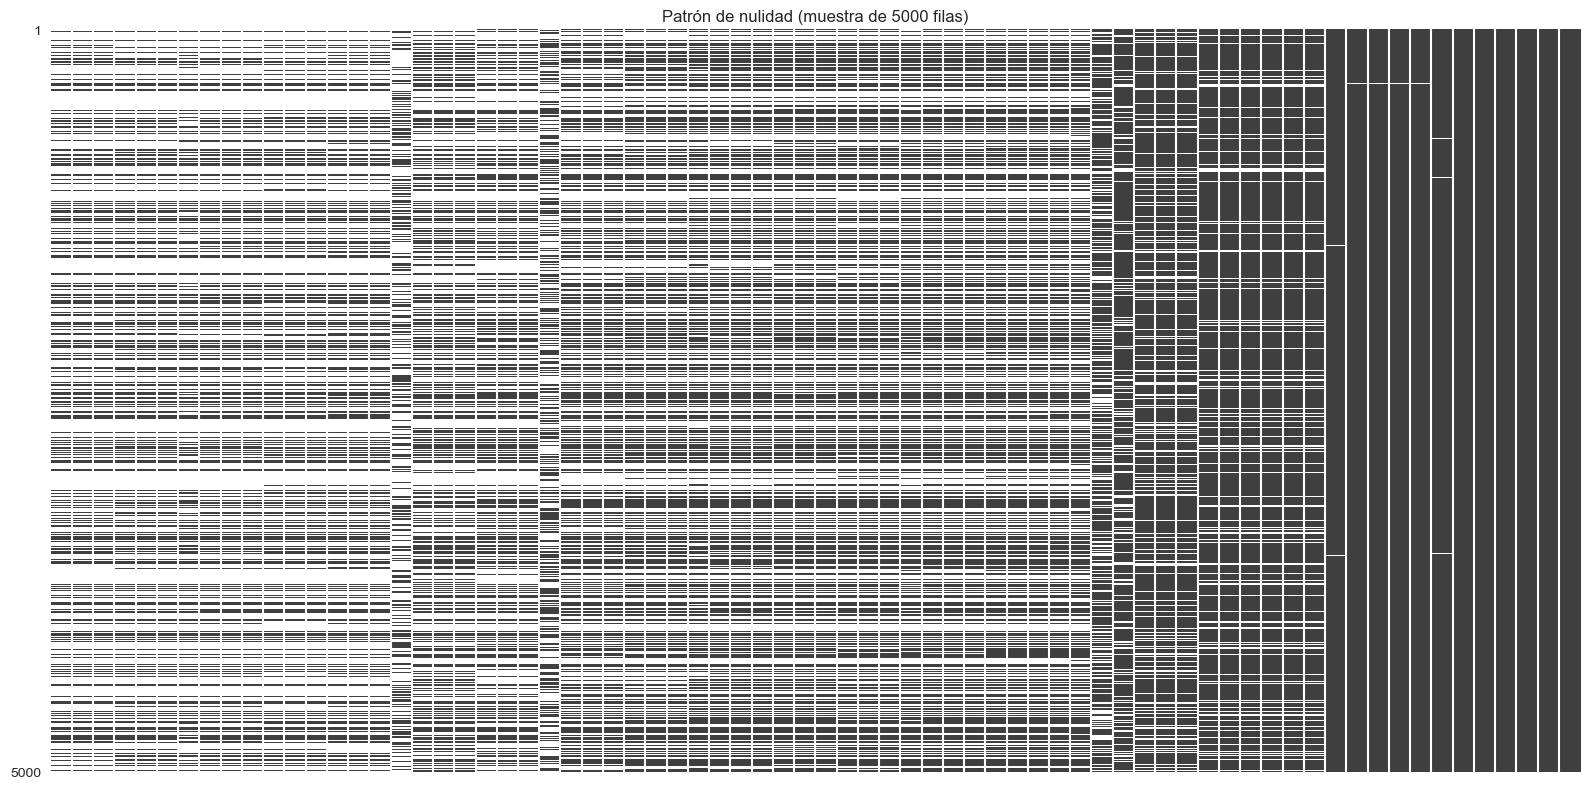

In [10]:
cols_with_nulls = nulls_df[nulls_df["n_nulls"] > 0].index.tolist()
print(f"Columnas con al menos un nulo: {len(cols_with_nulls)}")

# Muestra para que la matriz sea legible
sample = train_clean[cols_with_nulls].sample(5000, random_state=42)

fig, ax = plt.subplots(figsize=(16, 8))
msno.matrix(sample, sparkline=False, ax=ax, fontsize=8)
ax.set_title("Patrón de nulidad (muestra de 5000 filas)")
plt.tight_layout()
plt.savefig(REPORTS / "missingness_matrix.png", dpi=80, bbox_inches="tight")
plt.show()

In [11]:
train_clean.to_parquet(PROCESSED / "application_train_clean.parquet", index=False)
test_clean.to_parquet(PROCESSED / "application_test_clean.parquet", index=False)

mem_train = train_clean.memory_usage(deep=True).sum() / 1024**2
mem_test = test_clean.memory_usage(deep=True).sum() / 1024**2
print(f"Guardados:")
print(f"  application_train_clean.parquet  ({train_clean.shape[0]:,} × {train_clean.shape[1]}, {mem_train:.1f} MB)")
print(f"  application_test_clean.parquet   ({test_clean.shape[0]:,} × {test_clean.shape[1]}, {mem_test:.1f} MB)")

# Liberar memoria
del train, test
gc.collect()

Guardados:
  application_train_clean.parquet  (307,511 × 128, 348.5 MB)
  application_test_clean.parquet   (48,744 × 127, 55.2 MB)


3042